In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

$\text{Data Cleaning and Pre-Processing}$

In [19]:
orgData = pd.read_csv('diabetes.csv')
orgData

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [20]:
orgData = orgData.drop(columns=orgData.columns[[8]])
orgData

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [21]:
db = pd.DataFrame(data = orgData)
db = db.iloc[:,[0,1,2,3,5,6,7,4]]
db

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Insulin
0,6,148,72,35,33.6,0.627,50,0
1,1,85,66,29,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,0
3,1,89,66,23,28.1,0.167,21,94
4,0,137,40,35,43.1,2.288,33,168
...,...,...,...,...,...,...,...,...
763,10,101,76,48,32.9,0.171,63,180
764,2,122,70,27,36.8,0.340,27,0
765,5,121,72,23,26.2,0.245,30,112
766,1,126,60,0,30.1,0.349,47,0


In [22]:
#Pregnancies, Glucose, BloodPressure, SkinThickness, BMI, DiabetesPedigreeFunction, Age
X = db.iloc[:,[0,1,2,3,4,5,6]].to_numpy().reshape(-1, 7)
#Insulin
Y = db['Insulin'].to_numpy().reshape(-1, 1)
X
#print(X.shape)

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]])

In [23]:
Y
#print(Y.shape)

array([[  0],
       [  0],
       [  0],
       [ 94],
       [168],
       [  0],
       [ 88],
       [  0],
       [543],
       [  0],
       [  0],
       [  0],
       [  0],
       [846],
       [175],
       [  0],
       [230],
       [  0],
       [ 83],
       [ 96],
       [235],
       [  0],
       [  0],
       [  0],
       [146],
       [115],
       [  0],
       [140],
       [110],
       [  0],
       [  0],
       [245],
       [ 54],
       [  0],
       [  0],
       [192],
       [  0],
       [  0],
       [  0],
       [207],
       [ 70],
       [  0],
       [  0],
       [240],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [ 82],
       [ 36],
       [ 23],
       [300],
       [342],
       [  0],
       [304],
       [110],
       [  0],
       [142],
       [  0],
       [  0],
       [  0],
       [128],
       [  0],
       [  0],
       [  0],
       [  0],
       [ 38],
       [100],
       [ 90],
      

$\text{Machine Learning Algorithm}$

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, train_size=0.7, random_state=500)
print(X_train.shape)
X_train

(537, 7)


array([[  6.   , 151.   ,  62.   , ...,  35.5  ,   0.692,  28.   ],
       [  7.   , 136.   ,  74.   , ...,  26.   ,   0.647,  51.   ],
       [  0.   , 145.   ,   0.   , ...,  44.2  ,   0.63 ,  31.   ],
       ...,
       [  1.   , 119.   ,  86.   , ...,  45.6  ,   0.808,  29.   ],
       [  1.   , 108.   ,  60.   , ...,  35.5  ,   0.415,  24.   ],
       [  1.   ,  71.   ,  78.   , ...,  33.2  ,   0.422,  21.   ]])

In [25]:
print(X_test.shape)
X_test

(231, 7)


array([[3.00e+00, 1.70e+02, 6.40e+01, ..., 3.45e+01, 3.56e-01, 3.00e+01],
       [5.00e+00, 1.04e+02, 7.40e+01, ..., 2.88e+01, 1.53e-01, 4.80e+01],
       [9.00e+00, 1.40e+02, 9.40e+01, ..., 3.27e+01, 7.34e-01, 4.50e+01],
       ...,
       [1.20e+01, 1.21e+02, 7.80e+01, ..., 2.65e+01, 2.59e-01, 6.20e+01],
       [4.00e+00, 1.44e+02, 5.80e+01, ..., 2.95e+01, 2.87e-01, 3.70e+01],
       [3.00e+00, 8.00e+01, 0.00e+00, ..., 0.00e+00, 1.74e-01, 2.20e+01]])

In [26]:
print(Y_train.shape)
Y_train

(537, 1)


array([[120],
       [135],
       [  0],
       [  0],
       [  0],
       [ 64],
       [140],
       [180],
       [180],
       [100],
       [  0],
       [  0],
       [  0],
       [140],
       [152],
       [140],
       [  0],
       [  0],
       [274],
       [ 83],
       [  0],
       [  0],
       [  0],
       [  0],
       [326],
       [  0],
       [116],
       [167],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [ 54],
       [440],
       [200],
       [116],
       [  0],
       [  0],
       [  0],
       [105],
       [  0],
       [  0],
       [105],
       [  0],
       [210],
       [  0],
       [  0],
       [ 79],
       [  0],
       [  0],
       [  0],
       [744],
       [  0],
       [  0],
       [  0],
       [ 22],
       [342],
       [105],
       [127],
       [110],
       [  0],
       [ 70],
       [180],
       [  0],
       [148],
       [  0],
       [115],
       [265],
      

In [27]:
print(Y_test.shape)
Y_test

(231, 1)


array([[225],
       [  0],
       [  0],
       [114],
       [275],
       [  0],
       [  0],
       [  0],
       [140],
       [182],
       [ 57],
       [ 49],
       [126],
       [ 48],
       [  0],
       [  0],
       [  0],
       [  0],
       [140],
       [196],
       [129],
       [270],
       [115],
       [278],
       [  0],
       [  0],
       [  0],
       [  0],
       [  0],
       [ 15],
       [ 90],
       [185],
       [  0],
       [ 87],
       [120],
       [  0],
       [170],
       [210],
       [480],
       [144],
       [293],
       [115],
       [125],
       [  0],
       [  0],
       [370],
       [  0],
       [ 82],
       [ 67],
       [510],
       [  0],
       [110],
       [304],
       [115],
       [  0],
       [120],
       [  0],
       [ 54],
       [231],
       [325],
       [ 95],
       [  0],
       [  0],
       [152],
       [ 18],
       [  0],
       [ 74],
       [215],
       [ 94],
       [  0],
       [ 64],
      

In [28]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [29]:
cols = list(db)
print(model.coef_) #regression coefficients
coef_size = len(model.coef_[0])
for i in range(coef_size):
    print(cols[i], model.coef_[0][i])
print("Intercept = ",model.intercept_)

[[-1.62698308e+00  1.07747048e+00  2.07032030e-02  2.62795238e+00
  -8.89565667e-01  5.24790319e+01 -6.73648392e-01]]
Pregnancies -1.6269830772497653
Glucose 1.0774704823261796
BloodPressure 0.020703203000015998
SkinThickness 2.627952382571459
BMI -0.8895656667960069
DiabetesPedigreeFunction 52.479031912882554
Age -0.6736483924707067
Intercept =  [-81.27700581]


In [30]:
y_pred = model.predict(X_test)
y_pred

array([[ 1.63354338e+02],
       [-2.57482762e+01],
       [ 3.59887496e+01],
       [ 1.50759308e+02],
       [ 1.59063695e+02],
       [ 4.28198506e+01],
       [ 2.68284025e+01],
       [ 6.67906800e+01],
       [ 1.60703048e+02],
       [ 4.25408316e+01],
       [ 1.43978510e+02],
       [ 3.52822943e+01],
       [ 1.20816283e+02],
       [ 4.52032451e+01],
       [ 2.42784916e+01],
       [ 1.74287945e+02],
       [ 8.93595072e+01],
       [-1.23992371e+01],
       [ 1.27125573e+02],
       [ 6.89614462e+01],
       [ 1.15348569e+02],
       [ 7.09532657e+01],
       [ 4.24019374e+01],
       [ 6.83067137e+01],
       [ 5.39449292e+01],
       [ 1.05528564e+02],
       [ 3.71836179e+01],
       [-6.86172586e+01],
       [ 4.68841674e+01],
       [ 4.29692867e+00],
       [ 9.13941197e+01],
       [ 1.52280775e+02],
       [ 4.56029423e+00],
       [ 6.42991406e+01],
       [ 7.69278634e+01],
       [ 5.92083512e+01],
       [ 1.15579567e+02],
       [ 1.48860235e+02],
       [ 7.5

$\text{Data Analysis and Plots}$

In [31]:
mae = mean_absolute_error(Y_test, y_pred) 
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred) #Coefficient of Determination
print("Mean Absolute Error = ", mae)
print("Mean Squared Error = ", mse)
print("R2 Score = ", r2)

Mean Absolute Error =  73.49936012251497
Mean Squared Error =  14399.419435097076
R2 Score =  0.19978856059720163


MAE is significantly high which means that there is a significant error between the predicted and actual values for insulin. Therefore, the model's prediction does not align with the data

R2 Score is close to 0 which means that the prediction

(537, 1)
(231, 1)


ValueError: x and y must be the same size

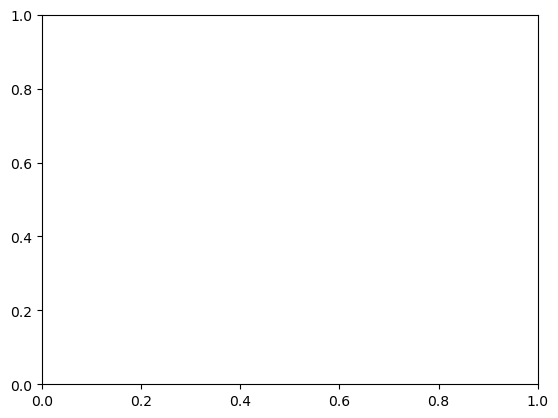

In [32]:
# print(Y_train.shape)
# print(y_pred.shape)
plt.scatter(Y_train, y_pred)
plt.xlabel("Actual Insulin Dosage")
plt.ylabel("Predicted Insulin Dosage")
#plt.plot(X_test,y_pred,color="red")
#plt.title("Regression Plot of Years of Experience VS Salary")
#plt.xlabel("Years of Experience")
#plt.ylabel("Salary")
#plt.legend(['Actual Values','Best Line or General formula'])
#plt.show()